### Vector Databases

A vector database in RAG is a specialized store for embeddings that allows fast similarity search, ensuring the LLM retrieves semantically relevant chunks to generate accurate answers.

example:-
```
"I love rasmalai"
↓
[0.12, -0.45, 0.89, ...]
```
- 10 vectors → easy
- 10,000 vectors → harder
- 1 million vectors → very hard

A vector database helps us quickly find:
"Which vectors are most similar to this query vector?"
```
This is called Similarity Search or Nearest Neighbor Search.


In [1]:
%pip install faiss-cpu chromadb sentence-transformers -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 104.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currentl

### generating 10,000 fake embeddings

In [2]:
import numpy as np
import time
vectors=np.random.rand(10000,384).astype('float32')
query=np.random.rand(1,384).astype('float32')
vectors.shape

(10000, 384)

### Benchmark FAISS

In [10]:
import faiss

#building faiss (adding vectors to the index)

start=time.time()
index=faiss.IndexFlatL2(384)
index.add(vectors)
build_time_faiss = time.time() - start
# search

start=time.time()
distances,indices=index.search(query,k=5)
search_time_faiss=time.time()-start

In [11]:
print(f"Search time : {search_time_faiss:.6f} sec")
print(f"Top 5 matches (vector IDs): {indices[0]}")
print(f"Their distances : {distances[0].round(3)}")

Search time : 0.003007 sec
Top 5 matches (vector IDs): [1761 7780 1574 1798 5644]
Their distances : [49.294 49.457 50.47  51.001 51.099]


### Benchmark ChromaDB

In [14]:
import chromadb

#creating ChromaDB client
client=chromadb.Client()

# A "collection" is like a table in a regular database
# Using get_or_create_collection to avoid error if collection already exists
collection = client.get_or_create_collection("my_vectors")

In [15]:
## Build (add vectors to CHromaDB)

start=time.time()
BATCH = 1000
for i in range(0, 10000, BATCH):
    batch_end = min(i + BATCH, 10000)
    collection.add(
        ids        = [str(j) for j in range(i, batch_end)],           # unique IDs
        embeddings = vectors[i:batch_end].tolist(),                    # the actual vectors
        documents  = [f"Document number {j}" for j in range(i, batch_end)]  # original text
    )

build_time_chroma=time.time()-start

##Searching

start=time.time()
results = collection.query(
    query_embeddings=query.tolist(),
    n_results=5
)

In [16]:
search_time_chroma = time.time()-start
print(f"Search time : {search_time_chroma:.6f} sec")
print(f"Top 5 matches (IDs): {results['ids'][0]}")
print(f"Their text (bonus!): {results['documents'][0]}")

Search time : 14.363195 sec
Top 5 matches (IDs): ['1761', '7780', '1574', '5644', '6152']
Their text (bonus!): ['Document number 1761', 'Document number 7780', 'Document number 1574', 'Document number 5644', 'Document number 6152']


FAISS vs ChromaDB — 10,000 Vectors
Build time  →  FAISS: 0.007s  |  ChromaDB: 1.076s
Search time →  FAISS: 0.00301s  |  ChromaDB: 14.36320s
FAISS is 4776.3x faster at search


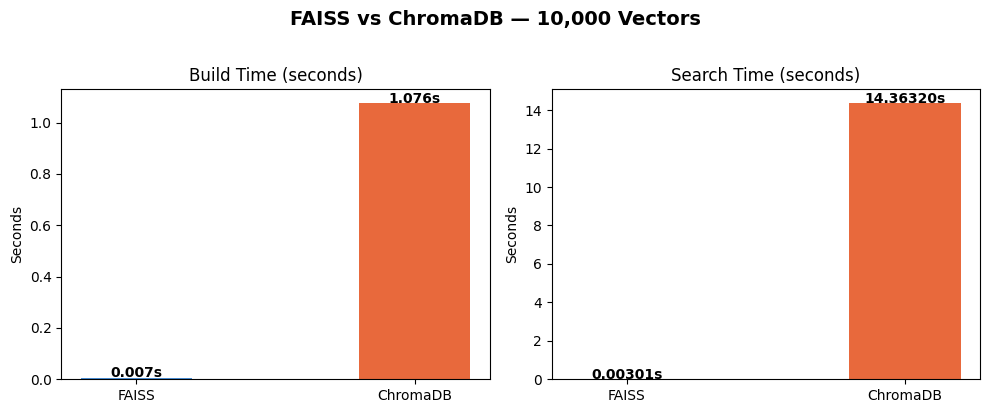

Chart saved as faiss_vs_chromadb.png  ← upload this to LinkedIn!


In [19]:
#comparison and visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print("FAISS vs ChromaDB — 10,000 Vectors")
print(f"Build time  →  FAISS: {build_time_faiss:.3f}s  |  ChromaDB: {build_time_chroma:.3f}s")
print(f"Search time →  FAISS: {search_time_faiss:.5f}s  |  ChromaDB: {search_time_chroma:.5f}s")
print(f"FAISS is {search_time_chroma / search_time_faiss:.1f}x faster at search")


#Bar chart
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("FAISS vs ChromaDB — 10,000 Vectors", fontsize=14, fontweight="bold", y=1.02)

labels = ["FAISS", "ChromaDB"]
colors = ["#4A90D9", "#E8693C"]

# Chart 1: Build time
axes[0].bar(labels, [build_time_faiss, build_time_chroma], color=colors, width=0.4)
axes[0].set_title("Build Time (seconds)", fontsize=12)
axes[0].set_ylabel("Seconds")
for i, v in enumerate([build_time_faiss, build_time_chroma]):
    axes[0].text(i, v + 0.001, f"{v:.3f}s", ha="center", fontweight="bold")

# Chart 2: Search time
axes[1].bar(labels, [search_time_faiss, search_time_chroma], color=colors, width=0.4)
axes[1].set_title("Search Time (seconds)", fontsize=12)
axes[1].set_ylabel("Seconds")
for i, v in enumerate([search_time_faiss, search_time_chroma]):
    axes[1].text(i, v + 0.00001, f"{v:.5f}s", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()
print("Chart saved as faiss_vs_chromadb.png  ← upload this to LinkedIn!")

In [18]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

#custom sentences
sentences = [
    "I love playing football on weekends",
    "Machine learning is changing the world",
    "The best pizza I ever had was in Naples",
    "Python is a great programming language",
    "Dogs are loyal and loving companions",
    "Deep learning requires a lot of data",
    "I enjoy cooking pasta at home",
    "Neural networks mimic the human brain",
    "Cats are independent and mysterious pets",
    "JavaScript runs in the browser",
]

# Create a fresh collection
client2 =chromadb.Client()
real_coll=client2.create_collection("real_sentences")
embeddings=model.encode(sentences).tolist()

real_coll.add(
    ids=[str(i) for i in range(len(sentences))],
    embeddings=embeddings,
    documents =sentences
)

# Searching for something!
query="I like animals as pets"
query_emb=model.encode([query]).tolist()
results=real_coll.query(query_embeddings=query_emb, n_results=3)

print(f"\nQuery: '{query}'")
print(f"\nTop 3 most similar sentences:")
for i, doc in enumerate(results["documents"][0]):
    print(f"   {i+1}. {doc}")



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


Query: 'I like animals as pets'

Top 3 most similar sentences:
   1. Cats are independent and mysterious pets
   2. Dogs are loyal and loving companions
   3. I love playing football on weekends
